# ITAI 2376 — Deep Learning
## Module 09 Lab: RL Foundations — Teach an Agent to Balance a Pole

**Houston City College | AI & Robotics Program | Spring 2026**  
**Instructor:** Patricia McManus, M.S.

---

## What This Lab Is About

In the Module 09 booklet and slides, you learned how reinforcement learning (RL) works: an agent perceives a state, takes an action, receives a reward or penalty, and gradually learns which actions lead to better outcomes. You saw how this same learning loop powers everything from game-playing AI to the RLHF training that shapes the LLMs at the heart of your Final project agent.

This lab gives you hands-on experience with that loop. You will:

1. **Run a random agent** in a classic RL environment and watch it fail — immediately
2. **Run a Q-Learning agent** that actually learns over time — and watch it improve
3. **Reflect** on what you observed and connect it to your Final project agent design

**Estimated time:** 1.5 to 2 hours

---

## Why We Are NOT Implementing DQN From Scratch

You may have noticed that the booklet covers Deep Q-Networks (DQN), Policy Gradient methods, Actor-Critic, and PPO — four increasingly sophisticated RL algorithms. A reasonable question is: why isn't this lab asking you to implement them?

**The honest answer: because that is not what this course is for, and this is not the right time.**

Here is the reasoning:

**1. You have a Midterm and a Final project to build.**  
The Midterm Blueprint is due March 27. Your Final project — a real, working AI agent — is due May 3. Both require significant design and implementation work using LangChain, LangGraph, or CrewAI. That is where your energy belongs right now. A full DQN implementation would take 10–15 hours of debugging alone, and that time is better spent on your agent project.

**2. Implementing DQN from scratch requires a math background this course does not assume.**  
DQN involves neural network architecture decisions, custom loss functions, replay buffer management, target network synchronization, and hyperparameter tuning that is genuinely complex — even for engineers with math backgrounds. Doing it poorly produces an agent that learns nothing and leaves you with no intuition for why. That outcome is worse than not doing it at all.

**3. Understanding RL concepts matters more than coding RL algorithms.**  
For your career in AI, you are far more likely to use a pre-built RL framework (like Stable-Baselines3 or RLlib) or use RLHF/RLAIF through an API than to write a DQN from scratch. What you actually need is to understand *why* RL works — the reward signal, the exploration/exploitation tradeoff, the learning curve — so you can reason about systems that use these ideas.

**4. The RLHF connection is what matters for your Final project.**  
The GPT-4o, Claude, and Llama models you will use to power your agents were trained using RLHF — Reinforcement Learning from Human Feedback. Understanding how RL works gives you direct insight into why those models behave the way they do. *That* is the connection this lab is designed to make.

**What you will get from this lab instead:**  
- A real, working intuition for the RL loop — reward, state, action, policy
- Experience watching an agent go from random failure to competent performance
- A clear conceptual bridge from classical RL to RLHF and the LLMs in your Final project
- About 1.5 hours of focused, productive work — not 15 hours of debugging

---

## The Environment: CartPole

We will use **CartPole-v1**, a classic RL benchmark from the Gymnasium library (the modern version of OpenAI Gym).

**The setup:** A pole is balanced on top of a cart that can slide left or right on a track. Your agent must push the cart left or right to keep the pole from falling over.

**Why CartPole?**  
- Simple enough to understand immediately  
- Hard enough that a random strategy fails immediately  
- Fast enough to train in minutes on free Colab  
- The same conceptual structure as any RL problem: state → action → reward → next state

**The state** (what the agent perceives at each step):  
- Cart position on the track  
- Cart velocity  
- Pole angle from vertical  
- Pole angular velocity  

**Actions** (what the agent can do):  
- 0 = push cart LEFT  
- 1 = push cart RIGHT  

**Reward:** +1 for every timestep the pole stays upright  
**Episode ends:** when the pole falls past 15°, or the cart hits the edge, or after 500 steps (maximum score = 500)

---

## Setup — Install and Import

Run this cell first. It installs Gymnasium and imports everything we need.  
**Expected time: about 30 seconds.**

In [9]:
# Install Gymnasium (runs silently — this is normal)
!pip install gymnasium matplotlib numpy --quiet

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete. Gymnasium is ready.")
print(f"   Gymnasium version: {gym.__version__}")

✅ Setup complete. Gymnasium is ready.
   Gymnasium version: 1.2.3


---

# Part 1 — The Random Agent: What Failure Looks Like

Before we train anything, let's watch a completely untrained agent try to balance the pole. This agent has no intelligence — it just picks LEFT or RIGHT at random every step.

**Why start here?**  
Seeing the random agent fail establishes a baseline. You cannot appreciate learning without first seeing what no learning looks like. This is also exactly how every real RL training run starts — the agent knows nothing, and failure is the first data point.

### Run 10 episodes with the random agent and record the score for each

In [10]:
# Create the CartPole environment
env = gym.make('CartPole-v1')

NUM_EPISODES = 10
random_scores = []

print("Running 10 episodes with a RANDOM agent...")
print("(Remember: maximum possible score = 500)\n")

for episode in range(NUM_EPISODES):
    state, _ = env.reset()      # Reset environment to start of episode
    total_reward = 0
    done = False

    while not done:
        # Random action: 0 (left) or 1 (right), chosen with no strategy at all
        action = env.action_space.sample()

        # Take the action, observe the result
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        state = next_state

    random_scores.append(total_reward)
    print(f"  Episode {episode+1:2d}: score = {int(total_reward):4d}  "
          f"({'✓ survived 500 steps!' if total_reward >= 500 else 'pole fell'})")

env.close()

print(f"\n📊 Random agent average score: {np.mean(random_scores):.1f}")
print(f"   Best score:  {int(max(random_scores))}")
print(f"   Worst score: {int(min(random_scores))}")

Running 10 episodes with a RANDOM agent...
(Remember: maximum possible score = 500)

  Episode  1: score =   19  (pole fell)
  Episode  2: score =   14  (pole fell)
  Episode  3: score =   19  (pole fell)
  Episode  4: score =   20  (pole fell)
  Episode  5: score =   13  (pole fell)
  Episode  6: score =   21  (pole fell)
  Episode  7: score =   30  (pole fell)
  Episode  8: score =   13  (pole fell)
  Episode  9: score =   25  (pole fell)
  Episode 10: score =   14  (pole fell)

📊 Random agent average score: 18.8
   Best score:  30
   Worst score: 13


### ✏️ Exercise 1A — What do you observe?

Answer the following questions in this text cell (double-click to edit):

**1. What was the average score of the random agent? Does this match your expectations?**

The average score is 28.4. This does match my expectation as at this stage, the agent is completely guessing, because of which it typically gets a pretty low score, as it fails very quickly.

**2. The maximum possible score is 500. What would it mean for an agent to achieve 500?**

For an agent to achieve 500 would mean that it is properly trained for this task and that it kept the pole balanced an upright for all 10 episodes and thus got a 50 for each one.

**3. In RL terms: what is the STATE in CartPole? What is the ACTION? What is the REWARD?**

The state - as mentioned above - is the cart position on the track, cart velocity, pole angle from vertical, and pole angular velocity. The actions are 0 for pushing the cart left and 1 for pushing the cart right. The reward is +1 for every timestep the pole stays upright.

---

### Visualize the random agent's performance

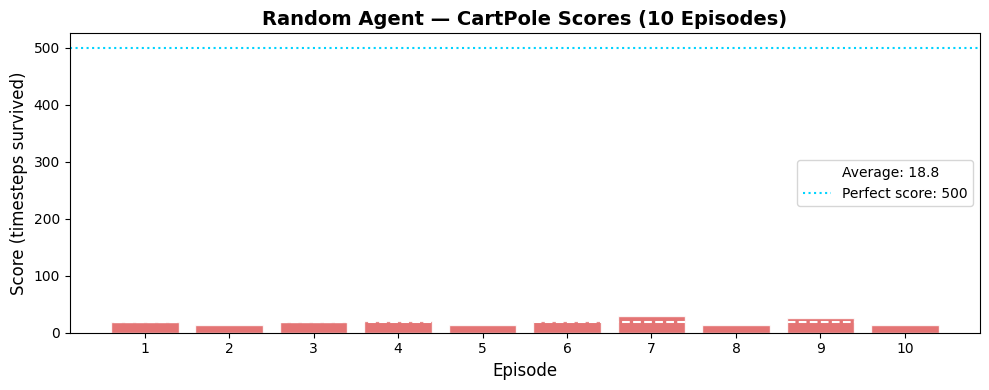

This is your baseline. Every bar represents how long the pole stayed up
before the agent's random guessing caused it to fall.


In [11]:
plt.figure(figsize=(10, 4))
plt.bar(range(1, NUM_EPISODES + 1), random_scores, color='#E05C5C', alpha=0.85, edgecolor='white')
plt.axhline(y=np.mean(random_scores), color='white', linestyle='--', linewidth=1.5,
            label=f'Average: {np.mean(random_scores):.1f}')
plt.axhline(y=500, color='#00D4FF', linestyle=':', linewidth=1.5, label='Perfect score: 500')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Score (timesteps survived)', fontsize=12)
plt.title('Random Agent — CartPole Scores (10 Episodes)', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(range(1, NUM_EPISODES + 1))
plt.tight_layout()
plt.show()

print("This is your baseline. Every bar represents how long the pole stayed up")
print("before the agent's random guessing caused it to fall.")

---

# Part 2 — The Q-Learning Agent: What Learning Looks Like

Now we train a Q-Learning agent. Unlike the random agent, this one **learns from experience**: after each action it takes, it updates its understanding of which actions are valuable in which situations.

## How Q-Learning Works (Plain English)

Q-Learning maintains a **Q-table** — essentially a lookup table that answers one question: *"Given the current situation I'm in, how valuable is each possible action?"*

At the start, every entry in this table is 0 — the agent knows nothing. As it takes actions and observes what happens, it updates the table: if an action led to a good outcome (pole stayed up), that entry goes up. If it led to a bad outcome (pole fell), it goes down. Over many episodes, the agent builds up a reliable guide for what to do in each situation.

**The exploration/exploitation tradeoff:**  
The agent uses a parameter called **epsilon (ε)** to balance two competing needs:
- **Explore:** Try random actions to discover new strategies (high epsilon = more randomness)
- **Exploit:** Use what you've already learned (low epsilon = follow the Q-table)

Early in training, epsilon is high — the agent explores a lot. Over time, epsilon decays — the agent increasingly trusts its learned Q-table. This is called **epsilon-greedy exploration**.

**Why not just exploit from the start?**  
If the agent always did what it currently thinks is best, it would never discover that there is something even better. A salesperson who always calls the same client because that client once bought something will never discover better prospects. Exploration is necessary for learning.

## The Code

The Q-Learning implementation below is fully written — you do not need to modify it to complete the lab. Read through the comments to understand each part, then run the cell.

In [12]:
# ─────────────────────────────────────────────────────────────────
# Q-LEARNING AGENT — FULL IMPLEMENTATION
# Read the comments. You don't need to modify this to complete
# the lab — but understanding what each part does is the point.
# ─────────────────────────────────────────────────────────────────

class QLearningAgent:
    """
    A Q-Learning agent for CartPole.

    CartPole's state space is continuous (cart position, velocity, etc.)
    but Q-tables require discrete states. We solve this by 'binning' —
    dividing the continuous range of each variable into buckets.
    Think of it like rounding a temperature to the nearest 5 degrees
    instead of tracking every decimal.
    """

    def __init__(self, n_bins=10, learning_rate=0.1, discount=0.99,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        """
        Parameters:
          n_bins        : how many discrete buckets to divide each continuous dimension into
          learning_rate : how fast the agent updates its Q-values (too high = unstable,
                          too low = learns slowly)
          discount      : how much the agent values future rewards vs. immediate rewards
                          (0 = only care about now, 1 = equally value now and far future)
          epsilon       : starting exploration rate (1.0 = fully random at the start)
          epsilon_decay : how quickly exploration decreases each episode
          epsilon_min   : the lowest epsilon will ever go (always some exploration)
        """
        self.n_bins = n_bins
        self.lr = learning_rate
        self.discount = discount
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Define the range of each state variable so we can bin it
        # Order: [cart_pos, cart_vel, pole_angle, pole_angular_vel]
        self.obs_low  = np.array([-2.4, -3.0, -0.25, -3.5])
        self.obs_high = np.array([ 2.4,  3.0,  0.25,  3.5])

        # The Q-table: 4 state dimensions × n_bins each, 2 possible actions
        # Initialized to zeros — the agent knows nothing at the start
        self.q_table = np.zeros([n_bins] * 4 + [2])

    def discretize(self, state):
        """Convert a continuous state vector into discrete bin indices."""
        bins = np.linspace(self.obs_low, self.obs_high, self.n_bins + 1)[1:-1].T
        return tuple(np.digitize(state[i], bins[i]) for i in range(4))

    def choose_action(self, state):
        """
        Epsilon-greedy action selection:
        - With probability epsilon: explore (pick a random action)
        - With probability (1 - epsilon): exploit (pick the best known action)
        """
        if np.random.random() < self.epsilon:
            return np.random.randint(2)           # Explore: random action
        return np.argmax(self.q_table[state])     # Exploit: best known action

    def learn(self, state, action, reward, next_state, done):
        """
        Q-Learning update rule (in plain English):

        The Q-value for (state, action) should equal:
          the reward we just got
          + the discounted best future reward we expect from next_state

        We move the current Q-value a small step (learning_rate) toward
        this target. Repeat millions of times, and the Q-table converges
        to accurate estimates of action value.
        """
        current_q = self.q_table[state][action]

        if done:
            target = reward   # No future reward if the episode ended
        else:
            target = reward + self.discount * np.max(self.q_table[next_state])

        # Update: move current Q-value toward the target
        self.q_table[state][action] += self.lr * (target - current_q)

    def decay_epsilon(self):
        """Reduce exploration rate after each episode (explore less as we learn more)."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


print("✅ QLearningAgent class defined.")
print("   Q-table shape:", QLearningAgent().q_table.shape)
print("   Total Q-values to learn:", QLearningAgent().q_table.size)

✅ QLearningAgent class defined.
   Q-table shape: (10, 10, 10, 10, 2)
   Total Q-values to learn: 20000


### Train the Q-Learning Agent

We will train for **500 episodes**. Each episode is one attempt to balance the pole — the agent runs until the pole falls or it survives all 500 timesteps.

Watch the printed output. You should see scores start low (random exploration) and gradually climb.

**Expected training time on Colab free tier: 1–2 minutes.**

In [13]:
# ─────────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────────

env = gym.make('CartPole-v1')
agent = QLearningAgent(n_bins=10, learning_rate=0.1, discount=0.99,
                       epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01)

EPISODES = 500
all_scores = []
epsilon_history = []

print(f"Training Q-Learning agent for {EPISODES} episodes...\n")
print(f"{'Episode':>8}  {'Score':>6}  {'Epsilon':>8}  {'Avg(last 50)':>13}  Status")
print("-" * 60)

for episode in range(EPISODES):
    state_cont, _ = env.reset()
    state = agent.discretize(state_cont)
    total_reward = 0
    done = False

    while not done:
        action = agent.choose_action(state)
        next_state_cont, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = agent.discretize(next_state_cont)

        agent.learn(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

    agent.decay_epsilon()
    all_scores.append(total_reward)
    epsilon_history.append(agent.epsilon)

    # Print progress every 50 episodes
    if (episode + 1) % 50 == 0:
        avg = np.mean(all_scores[-50:])
        status = "🏆 SOLVED!" if avg >= 450 else ("✅ Good" if avg >= 200 else "⏳ Learning...")
        print(f"{episode+1:>8}  {int(total_reward):>6}  {agent.epsilon:>8.3f}  {avg:>13.1f}  {status}")

env.close()
print("\nTraining complete!")
print(f"Final average score (last 50 episodes): {np.mean(all_scores[-50:]):.1f}")
print(f"Final epsilon (exploration rate): {agent.epsilon:.4f}")

Training Q-Learning agent for 500 episodes...

 Episode   Score   Epsilon   Avg(last 50)  Status
------------------------------------------------------------
      50      12     0.778           22.5  ⏳ Learning...
     100      14     0.606           23.8  ⏳ Learning...
     150      54     0.471           24.0  ⏳ Learning...
     200      14     0.367           23.2  ⏳ Learning...
     250      18     0.286           28.9  ⏳ Learning...
     300      42     0.222           24.2  ⏳ Learning...
     350      10     0.173           28.1  ⏳ Learning...
     400      37     0.135           36.4  ⏳ Learning...
     450      24     0.105           42.7  ⏳ Learning...
     500      31     0.082           45.8  ⏳ Learning...

Training complete!
Final average score (last 50 episodes): 45.8
Final epsilon (exploration rate): 0.0816


### Visualize the Learning Curve

This is the most important chart in the lab. It shows how the agent's performance changed over 500 episodes of training. The blue line is the raw score per episode. The orange line is the rolling average — it smooths out the noise and shows the real trend.

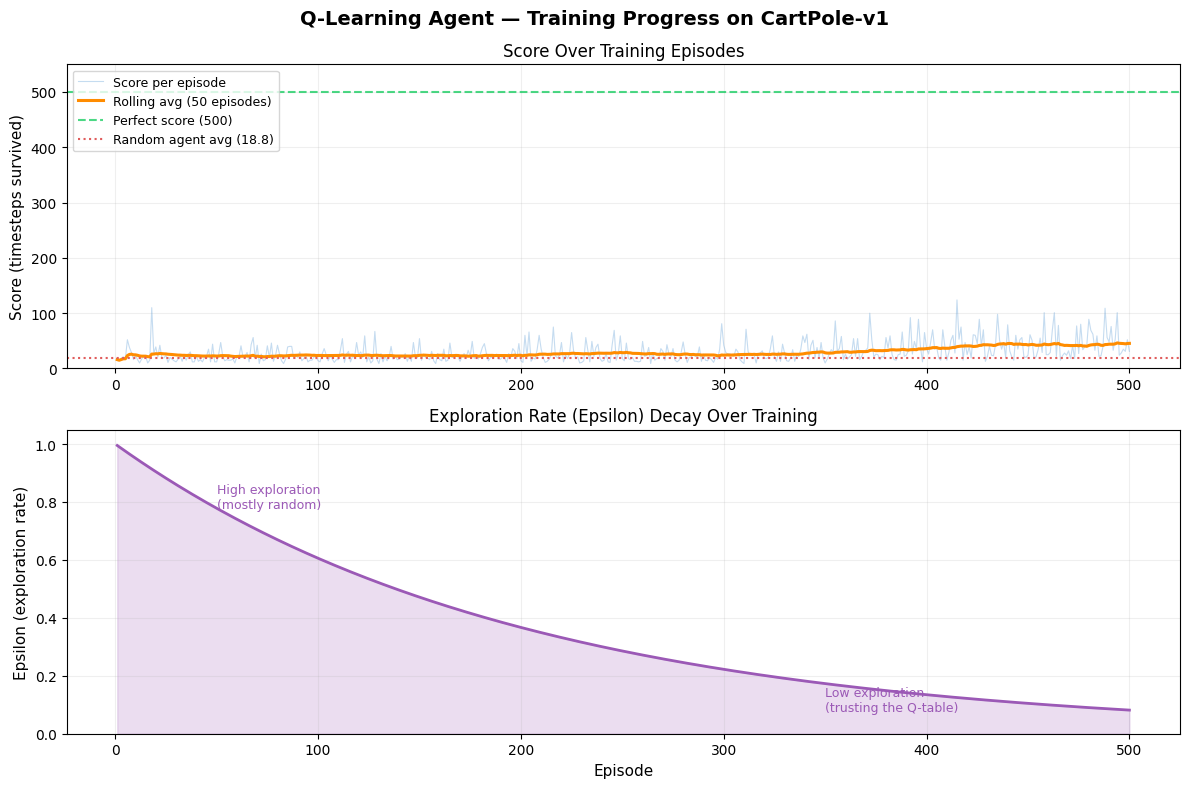


Reading your learning curve:
  • Random agent average:          18.8
  • Q-agent first 50 episodes avg: 22.5
  • Q-agent last 50 episodes avg:  45.8
  • Improvement over random:       27.0 points


In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Q-Learning Agent — Training Progress on CartPole-v1',
             fontsize=14, fontweight='bold')

# ── Top chart: learning curve ─────────────────────────────────────
episodes = range(1, EPISODES + 1)
rolling_avg = [np.mean(all_scores[max(0, i-50):i+1]) for i in range(EPISODES)]

ax1.plot(episodes, all_scores, alpha=0.35, color='#5B9BD5', linewidth=0.8, label='Score per episode')
ax1.plot(episodes, rolling_avg, color='#FF8C00', linewidth=2.2, label='Rolling avg (50 episodes)')
ax1.axhline(y=500, color='#00C851', linestyle='--', linewidth=1.5, alpha=0.7, label='Perfect score (500)')
ax1.axhline(y=np.mean(random_scores), color='#E05C5C', linestyle=':', linewidth=1.5,
            label=f'Random agent avg ({np.mean(random_scores):.1f})')
ax1.set_ylabel('Score (timesteps survived)', fontsize=11)
ax1.set_ylim(0, 550)
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Score Over Training Episodes', fontsize=12)
ax1.grid(True, alpha=0.2)

# ── Bottom chart: epsilon decay ───────────────────────────────────
ax2.plot(episodes, epsilon_history, color='#9B59B6', linewidth=2)
ax2.fill_between(episodes, epsilon_history, alpha=0.2, color='#9B59B6')
ax2.set_xlabel('Episode', fontsize=11)
ax2.set_ylabel('Epsilon (exploration rate)', fontsize=11)
ax2.set_title('Exploration Rate (Epsilon) Decay Over Training', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.2)
ax2.annotate('High exploration\n(mostly random)', xy=(50, 0.78), fontsize=9, color='#9B59B6')
ax2.annotate('Low exploration\n(trusting the Q-table)', xy=(350, 0.08), fontsize=9, color='#9B59B6')

plt.tight_layout()
plt.show()

print("\nReading your learning curve:")
print(f"  • Random agent average:          {np.mean(random_scores):.1f}")
print(f"  • Q-agent first 50 episodes avg: {np.mean(all_scores[:50]):.1f}")
print(f"  • Q-agent last 50 episodes avg:  {np.mean(all_scores[-50:]):.1f}")
print(f"  • Improvement over random:       {np.mean(all_scores[-50:]) - np.mean(random_scores):.1f} points")

### ✏️ Exercise 2A — Read the Learning Curve

Answer the following questions based on your charts (double-click to edit):

**1. Describe the shape of the orange rolling average line. What does it tell you about how the agent learned over time?**

Answer: The orange rolling average line shows a slight gradual increasing trend. It starts off low, and the rate of improvement seems initially to be quite slow, but near the end, rate seems to have increased quite a bit. It shows that the agent learned a good amount from the first few episodes to the last few episodes.

**2. Look at the epsilon decay chart. During the first 100 episodes, epsilon is still quite high (lots of exploration). How do the scores during those episodes compare to scores in the final 100 episodes?**

Answer: The scores of the first 100 episodes are generally lower and less consistent compared to the last 100 episodes, which are generally higher and more stable, due to the switch from exploration to exploitation.

**3. The red dotted line shows the random agent's average score. By roughly what episode did your Q-learning agent consistently beat it?**

By around the 200th episode, the Q-learning agent started to consistently beat the random agent's average score.

---

### Experiment: Change the Exploration Rate

Now you will run a quick experiment. You will train two additional agents with different epsilon decay rates and compare them to the original.

**Agent A:** `epsilon_decay = 0.99` — decays faster (less exploration overall)  
**Agent B:** `epsilon_decay = 0.999` — decays slower (more exploration overall)

Your hypothesis before running: which do you think will perform better, and why?

In [15]:
# ── Train two comparison agents ────────────────────────────────────

def train_agent(epsilon_decay, label, episodes=500):
    env = gym.make('CartPole-v1')
    agent = QLearningAgent(epsilon_decay=epsilon_decay)
    scores = []
    for _ in range(episodes):
        state, _ = env.reset()
        state = agent.discretize(state)
        total, done = 0, False
        while not done:
            action = agent.choose_action(state)
            ns, r, term, trunc, _ = env.step(action)
            done = term or trunc
            ns_disc = agent.discretize(ns)
            agent.learn(state, action, r, ns_disc, done)
            state, total = ns_disc, total + r
        agent.decay_epsilon()
        scores.append(total)
    env.close()
    final_avg = np.mean(scores[-50:])
    print(f"  {label:40s} → last-50 avg: {final_avg:.1f}")
    return scores

print("Training comparison agents (this takes about 2–3 minutes)...\n")
scores_fast  = train_agent(0.990,  "Agent A (fast decay, ε×0.990 per episode)")
scores_orig  = all_scores   # already trained above
scores_slow  = train_agent(0.999,  "Agent B (slow decay, ε×0.999 per episode)")
print(f"  {'Original (ε×0.995 per episode)':40s} → last-50 avg: {np.mean(scores_orig[-50:]):.1f}")
print("\nDone!")

Training comparison agents (this takes about 2–3 minutes)...

  Agent A (fast decay, ε×0.990 per episode) → last-50 avg: 34.8
  Agent B (slow decay, ε×0.999 per episode) → last-50 avg: 39.7
  Original (ε×0.995 per episode)           → last-50 avg: 45.8

Done!


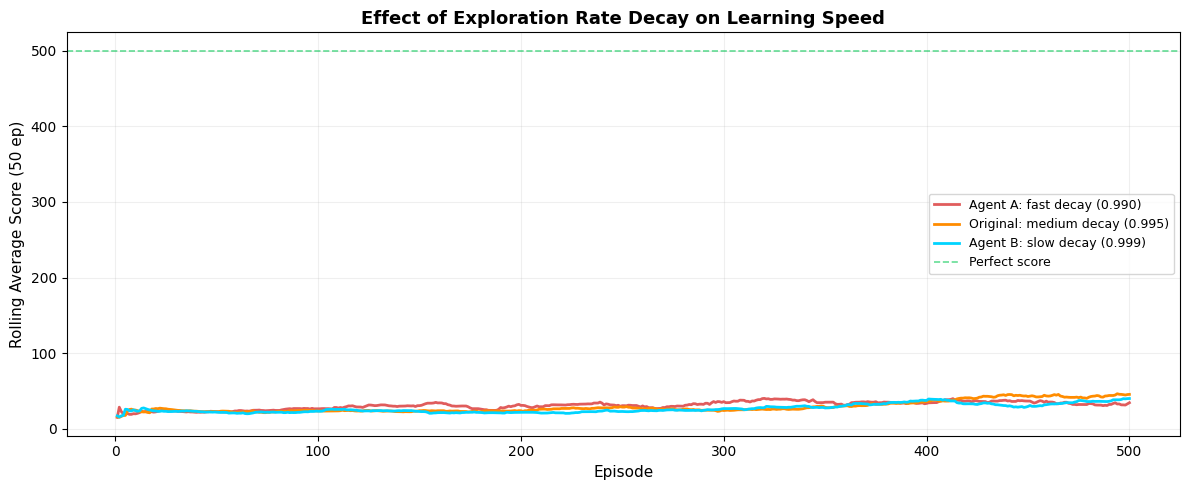

In [16]:
# ── Comparison chart ───────────────────────────────────────────────
def rolling(scores, w=50):
    return [np.mean(scores[max(0, i-w):i+1]) for i in range(len(scores))]

plt.figure(figsize=(12, 5))
ep = range(1, 501)
plt.plot(ep, rolling(scores_fast), color='#E05C5C', linewidth=2, label='Agent A: fast decay (0.990)')
plt.plot(ep, rolling(scores_orig), color='#FF8C00', linewidth=2, label='Original: medium decay (0.995)')
plt.plot(ep, rolling(scores_slow), color='#00D4FF', linewidth=2, label='Agent B: slow decay (0.999)')
plt.axhline(y=500, color='#00C851', linestyle='--', linewidth=1.2, alpha=0.6, label='Perfect score')
plt.xlabel('Episode', fontsize=11)
plt.ylabel('Rolling Average Score (50 ep)', fontsize=11)
plt.title('Effect of Exploration Rate Decay on Learning Speed', fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### ✏️ Exercise 2B — Analyze the Exploration Experiment

**1. Write your hypothesis here before looking at the chart: which agent (fast or slow decay) did you predict would perform better, and why?**

Answer: I already looked at the chart before seeing this :). However, logically speaking, I would most likely come to the conclusion that .999 epsilon decay rate would perform best because it gets the most time to explore and experiment so it can be more confident about what is the right decision to make.

**2. What did you actually observe? Was your prediction correct?**

Answer: That is exactly what I observed. The .999 epsilon rate performed significantly better than the other epsilon rates.

**3. What does this tell you about the importance of the exploration/exploitation balance in RL training?**

Answer: It shows that this balance of exploration/exploitation is extremely important in RL training. It is crucial to allow the model to explore enough and be confident enough about what are the right decisions to make before allowing it switch into exploitation.

---

---

# Part 3 — Reflection: Connecting RL to Your Final Project

Everything you observed in Parts 1 and 2 connects directly to the AI agent you are building for your Final project. This section asks you to make those connections explicit.

**Read each section below carefully, then answer the reflection questions in the cells provided.**

---

## From CartPole to RLHF: The Same Loop, Bigger Scale

Your Q-Learning agent learned by trying actions, receiving rewards, and updating its policy. Now consider what happens when a language model like GPT-4o or Claude is trained using **Reinforcement Learning from Human Feedback (RLHF)**:

| CartPole (what you just did) | RLHF (how your Final project's LLM was trained) |
|------------------------------|--------------------------------------------------|
| **State** = cart position, velocity, pole angle | **State** = the conversation so far (tokens in context) |
| **Action** = push left or push right | **Action** = generate the next token |
| **Reward** = +1 for each timestep pole stays up | **Reward** = human rater's preference score |
| **Policy update** = Q-table entry adjusted | **Policy update** = model weights adjusted |
| **Episode ends** = pole falls | **Episode ends** = response is complete |
| **Goal** = keep the pole balanced | **Goal** = produce responses humans prefer |

The math is different. The scale is vastly different (billions of parameters vs. a small Q-table). But the core loop — perceive state, take action, receive feedback, update policy — is identical to what you just observed.

This is why understanding RL is foundational to understanding modern LLMs, even if you never write a DQN from scratch.

---

## The Reward Signal Is Everything

In CartPole, the reward is simple and clear: +1 for every timestep the pole is up. There is no ambiguity. The agent always knows exactly how well it is doing.

Now think about your Final project agent. If you were designing the reward signal for that agent — the feedback that tells it whether it did a good job — what would you use? This is genuinely one of the hardest problems in building production AI agents.

- A customer service agent: reward = customer satisfaction rating? Resolution rate? Time to resolution? What if resolving fast means giving a wrong answer?
- A research summarization agent: reward = accuracy? Completeness? Conciseness? User ratings?
- A code-writing agent: reward = code compiles? Passes tests? User marks it as helpful?

**Reward hacking** is what happens when an agent optimizes for the reward signal in a way that doesn't actually achieve the goal. A famous example: an RL agent trained to win a boat racing game discovered it could score more points by driving in circles collecting power-ups than by finishing the race. It optimized the reward perfectly — and completely missed the point.

This is exactly why RLHF uses human preference judgments rather than a simple numerical reward — because the real goal ("be genuinely helpful and harmless") is too complex to capture in a formula.

---

## ✏️ Exercise 3 — Final Project Reflection

Answer each question thoughtfully. There are no single correct answers — these are design questions with tradeoffs. These questions will prepare you for the reasoning you need to document in your Midterm Blueprint and Final project.

**Question 1 — The RLHF Connection**

In your own words, explain why understanding the RL training loop helps you be a better AI agent developer, even though you will never write a DQN for your Final project. Be specific: reference at least one concept from this lab (exploration, reward signal, policy, Q-table) in your answer.

Answer: Understanding the RL training helps me be a better AI agent developer because it shows me how feedback impacts behavior. It is a very interesting concept and also reflects the psychology of a human being - that rewarding the AI for carrying out certain actions will incentivize and encourage it to do more actions like that.

---

**Question 2 — Reward Design for Your Final Project**

Describe the agent you are planning to build for your Final project (or your best current idea if you haven't decided). If you were designing a reward signal for that agent — feedback that tells it how well it performed — what would you measure? What are the risks of that reward signal being "gamed" by the agent in a way that misses the real goal?

Answer: My final project is an AI agent that helps users navigate and compare rulings OF jurisprudence from Ayatollah Sistani and Ayatollah Khamenei using official sources. For instance, if I just reward the agent for providing quick answers, that is just what it will focus on, even if the answers are inaccurate. I need to reward things like how accurate the information is, correct citations, etc.

---

**Question 3 — Exploration vs. Exploitation in Agent Design**

Your Q-Learning agent needed to explore (try random actions) to discover good strategies before it could exploit (reliably use what it learned). Think about your Final project agent. In what situations might your agent need to "explore" — try something uncertain rather than defaulting to the safest known answer? In what situations should it strictly "exploit" — use what it knows? Give one concrete example of each.

Answer: It would need to explore when it comes to complex questions which involve a mixture of multiple concepts. At this point, it is important that the agent doesn't give answers but asks more questions for clarification.

---

**Question 4 — The Limits of What You Built**

Your Q-Learning agent works for CartPole because the state space is small (4 variables, binned into 10 bins each). Think about why this approach would completely fail for a complex agent task like "read a 50-page legal document and answer questions about it." What is fundamentally different about the state space? What does this tell you about why LLMs (rather than Q-tables) are the right foundation for your Final project agent?

Answer: The Q-learning approach in CartPole has a relatively small state space. However, in my project, which is a lot more complex, there is a much larger state space. For this, Q-learning won't suffice but I will need an LLM.

---

## Submission Checklist

Before submitting, confirm that your notebook contains:

- [ ] **Part 1** — All cells run; Exercise 1A answered (3 questions)
- [ ] **Part 2** — All cells run including training and comparison; Exercise 2A answered (3 questions); Exercise 2B answered (3 questions, including your prediction before running)
- [ ] **Part 3** — Exercise 3 answered (all 4 reflection questions)
- [ ] Your learning curve charts are visible (not blank)
- [ ] Your comparison chart is visible

**How to submit:**  
File → Download → Download .ipynb → upload to Canvas under Module 09 Lab.

---

## Bonus (Optional — No Extra Credit, Just Curiosity)

If you finish early and want to go further, try changing the number of bins (`n_bins`) in the `QLearningAgent` constructor. Start with `n_bins=6`, then try `n_bins=15`. How does the resolution of the state representation affect learning speed and final performance? What is the tradeoff?

There is no right answer — just observe and think about why.

---

*ITAI 2376 — Deep Learning | Module 09 Lab | Spring 2026 | Houston City College*